In [9]:
###
### --- STUDENT PERFORMANCE PREDICTION --- ###
"""
Early predictive classification model that estimates the probability of student academic failure based on socio-academic factors
(Early prediction of student academic failure risk)
"""
###

'\nEarly predictive classification model that estimates the probability of student academic failure based on socio-academic factors\n(Early prediction of student academic failure risk)\n'

In [10]:
import sys
print(sys.executable)

/opt/anaconda3/envs/stats/bin/python


In [11]:
import numpy as np
import pandas as pd
import matplotlib as mtpl
import matplotlib.pyplot as plt 
import seaborn as sns 

from sklearn.model_selection import train_test_split

%matplotlib inline
sns.set(style="whitegrid")

%load_ext autoreload
%autoreload 2

print("\tPython ",sys.version)
print("\tpandas: ",pd.__version__)
print("\tnumpy: ",np.__version__)
print("\tmatplotlib: ",mtpl.__version__)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
	Python  3.11.14 (main, Oct 21 2025, 18:27:30) [Clang 20.1.8 ]
	pandas:  2.3.3
	numpy:  2.4.2
	matplotlib:  3.10.7


In [13]:
df_mat = pd.read_csv("../data-student/student-mat.csv", sep=";")
df_por = pd.read_csv("../data-student/student-por.csv", sep=";")

In [14]:
# first 5 lines of dataset 
df_mat.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [15]:
df_mat.shape

(395, 33)

In [16]:
df_mat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [17]:
df_mat.describe()

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


In [18]:
# target variable - detect risk 
df_mat["risk"] = (df_mat["G3"] < 10).astype(int)
df_mat["risk"].value_counts()
# G3 >= 10 => Success(0) - Risk = 0 False
# G3 < 10 => Fail(1) - Risk = 1 True 

risk
0    265
1    130
Name: count, dtype: int64

In [19]:
# percentage
df_mat["risk"].value_counts(normalize=True)

risk
0    0.670886
1    0.329114
Name: proportion, dtype: float64

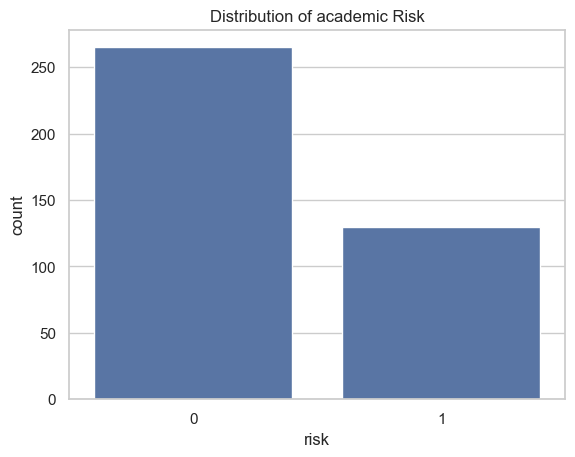

In [88]:
sns.countplot(x="risk", data=df_mat)
plt.title("Distribution of academic Risk")
plt.savefig("../src/distribution_academic_risk.png")
plt.show()

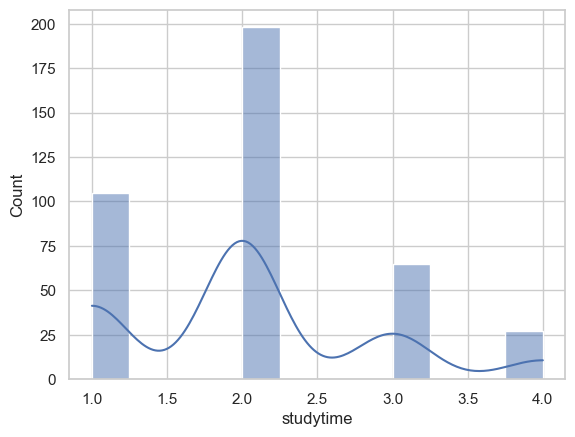

In [89]:
# Potentially strong predictors: studytime, (previous) failures, absences, G1, G2
# show which variables correlate risk classes

# studytime
sns.histplot(df_mat["studytime"], kde=True)
plt.savefig("../src/studytime.png")

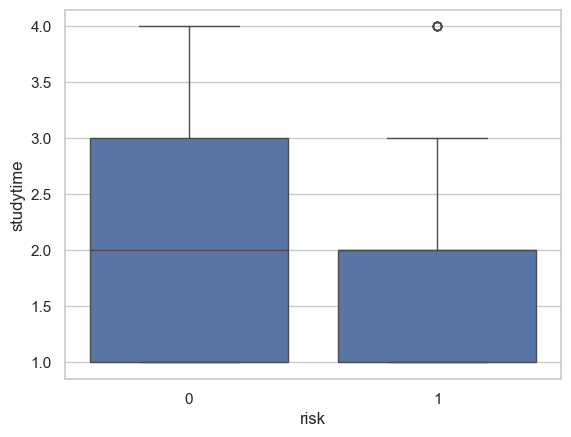

In [90]:
sns.boxplot(x="risk", y="studytime", data=df_mat)
plt.savefig("../src/studytime_box.png")

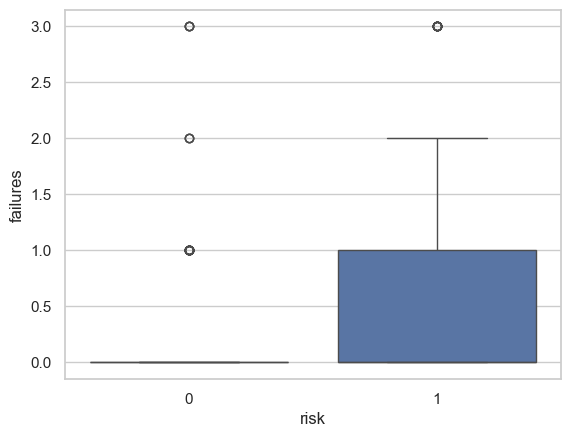

In [92]:
# (previous) failures
sns.boxplot(x="risk", y="failures", data=df_mat)
plt.savefig("../src/failures_box.png")

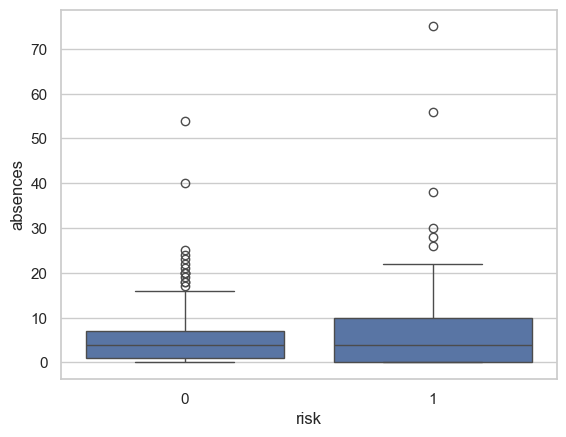

In [93]:
# absences
sns.boxplot(x="risk", y="absences", data=df_mat)
plt.savefig("../src/absences_box.png")

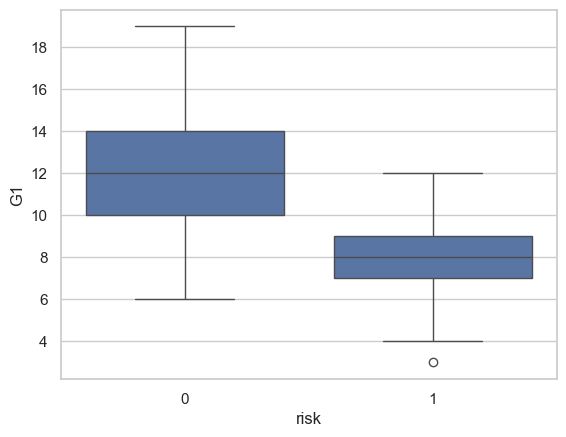

In [94]:
# G1
sns.boxplot(x="risk", y="G1", data=df_mat)
plt.savefig("../src/G1_box.png")

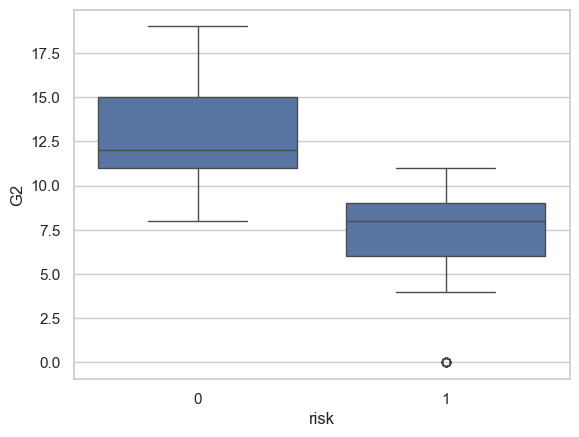

In [95]:
# G2
sns.boxplot(x="risk", y="G2", data=df_mat)
plt.savefig("../src/G2_box.png")

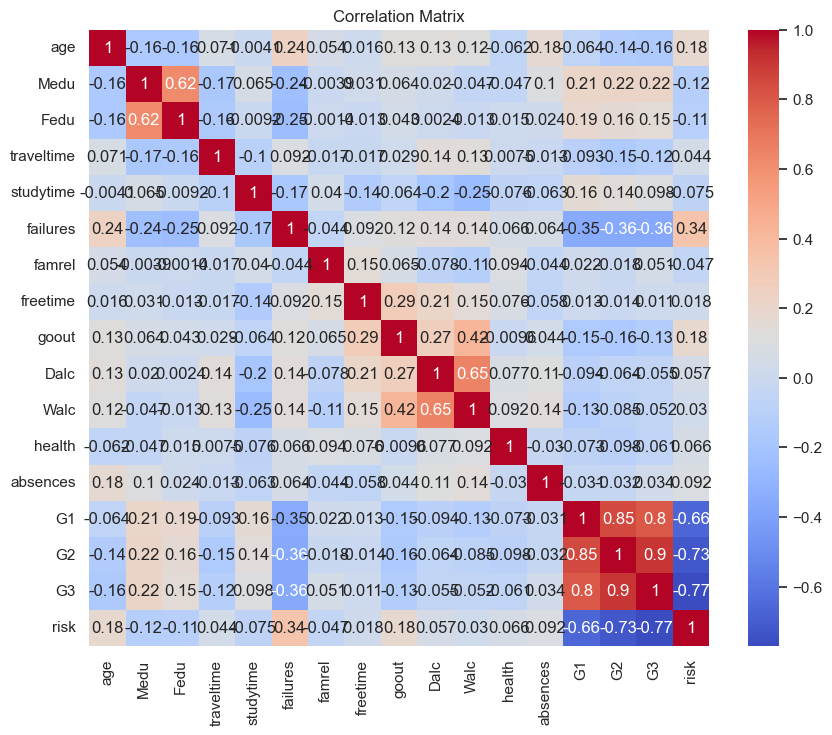

In [96]:
# check correlation between (studytime, (previous) failures, absences, G1, G2) vs G3
plt.figure(figsize=(10,8))
sns.heatmap(df_mat.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")

plt.savefig("../src/correlation_matrix.png")
plt.show()

In [97]:
# categorical variables (optional)
# do students want higher education fail less?
#sns.countplot(x="higher", hue="risk", data=df_mat)

In [98]:
# do students with famsup fail less?
#sns.countplot(x="famsup", hue="risk", data=df_mat)

In [99]:
# compare means by risk (optional)
# average differences between risk groups
df_mat.groupby("risk").mean(numeric_only=True)

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
risk,,,,,,,,,,,,,,,,
0,16.535849,2.837736,2.603774,1.426415,2.079245,0.158491,3.973585,3.222642,2.966038,1.445283,2.264151,3.490566,5.192453,12.452830,12.622642,12.883019
1,17.023077,2.569231,2.353846,1.492308,1.946154,0.692308,3.884615,3.261538,3.400000,1.553846,2.346154,3.684615,6.761538,7.761538,6.823077,5.384615


In [100]:
df_mat.corr(numeric_only=True)["G3"].sort_values(ascending=False)

G3            1.000000
G2            0.904868
G1            0.801468
Medu          0.217147
Fedu          0.152457
studytime     0.097820
famrel        0.051363
absences      0.034247
freetime      0.011307
Walc         -0.051939
Dalc         -0.054660
health       -0.061335
traveltime   -0.117142
goout        -0.132791
age          -0.161579
failures     -0.360415
risk         -0.770042
Name: G3, dtype: float64

In [32]:
### Part 3: Data Preprocessing ###

In [33]:
# Define features and Target
# features : everything except "G3" and "risk"
X = df_mat.drop(columns = ["G3", "risk"])

# Target : "risk"
Y = df_mat["risk"] # 0 or 1

In [34]:
# categorical variables :
X.select_dtypes(include="object").columns

# ML cannot read text categories
# so must convert them into numbers

Index(['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob',
       'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities',
       'nursery', 'higher', 'internet', 'romantic'],
      dtype='object')

In [35]:
# Encode categorical variables :
# One-hot Encoding :
X_encoded = pd.get_dummies(X, dtype=int) # convert categorie 'object' into 'int64'
X_encoded

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,...,activities_no,activities_yes,nursery_no,nursery_yes,higher_no,higher_yes,internet_no,internet_yes,romantic_no,romantic_yes
0,18,4,4,2,2,0,4,3,4,1,...,1,0,0,1,0,1,1,0,1,0
1,17,1,1,1,2,0,5,3,3,1,...,1,0,1,0,0,1,0,1,1,0
2,15,1,1,1,2,3,4,3,2,2,...,1,0,0,1,0,1,0,1,1,0
3,15,4,2,1,3,0,3,2,2,1,...,0,1,0,1,0,1,0,1,0,1
4,16,3,3,1,2,0,4,3,2,1,...,1,0,0,1,0,1,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,20,2,2,1,2,2,5,5,4,4,...,1,0,0,1,0,1,1,0,1,0
391,17,3,1,2,1,0,2,4,5,3,...,1,0,1,0,0,1,0,1,1,0
392,21,1,1,1,1,3,5,5,3,3,...,1,0,1,0,0,1,1,0,1,0
393,18,3,2,3,1,0,4,4,1,3,...,1,0,1,0,0,1,0,1,1,0


In [36]:
### Part 4: Model Training ###

In [37]:
# train / test split : using 80% of data to train the model and 20% to evaluate how well it learns 
X_train, X_test, y_train, y_test = train_test_split(X_encoded, Y, test_size=0.2, random_state=42, shuffle=True, stratify=Y)
                                                    
print('X_train : ')
print(X_train.head())
print('')
print('X_test : ')
print(X_test.head())
print('')
print('y_train : ')
print(y_train.head())
print('')
print('y_test : ')
print(y_test.head())

X_train : 
     age  Medu  Fedu  traveltime  studytime  failures  famrel  freetime  \
101   16     4     4           1          3         0       4         4   
63    16     4     3           1          3         0       3         4   
245   16     2     1           3          1         0       4         3   
112   16     2     2           1          2         1       3         1   
8     15     3     2           1          2         0       4         2   

     goout  Dalc  ...  activities_no  activities_yes  nursery_no  nursery_yes  \
101      3     1  ...              0               1           0            1   
63       4     2  ...              0               1           0            1   
245      3     1  ...              1               0           0            1   
112      2     1  ...              0               1           0            1   
8        2     1  ...              1               0           0            1   

     higher_no  higher_yes  internet_no  internet_y

In [38]:
# Feature scaling : normalize the range of variables (features)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) # fit scaler on X_train
X_test_scaled = scaler.transform(X_test) # test set remains unseen, if not the information'd be leaked

In [39]:
### Part 5: Model Evaluation ###

In [40]:
# LOGISTIC REGRESSION model : for classification problems, predicts the probability of a binary outcome
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=42, max_iter=1000)

# training
log_reg.fit(X_train_scaled, y_train)

# predictions
y_pred = log_reg.predict(X_test_scaled) # predicts class 0 (safe) or 1 (risk) for students
y_prob = log_reg.predict_proba(X_test_scaled)[:, 1] # probability that a student belongs to class 1 - at risk

In [41]:
print(np.mean(np.round(X_train_scaled, 2)))
print(np.std(X_train_scaled))

-0.00027989960715844777
1.0


In [42]:
np.round(X_train_scaled[:5], 2)

array([[-0.53,  1.17,  1.33, -0.64,  1.2 , -0.45,  0.02,  0.71, -0.1 ,
        -0.53, -1.  ,  0.34, -0.76,  1.52,  1.67,  0.36, -0.36, -1.05,
         1.05, -0.52,  0.52,  0.64, -0.64, -0.34,  0.34, -0.4 , -0.3 ,
        -0.74,  1.65, -0.43, -0.21, -0.25, -1.11, -0.63,  3.66, -0.77,
        -0.62,  3.15, -0.6 ,  1.87, -1.53, -0.29,  0.38, -0.38, -0.77,
         0.77,  0.94, -0.94, -1.01,  1.01, -0.49,  0.49, -0.25,  0.25,
        -0.44,  0.44, -1.43,  1.43],
       [-0.53,  1.17,  0.42, -0.64,  1.2 , -0.45, -1.1 ,  0.71,  0.77,
         0.6 ,  1.3 ,  0.34, -0.49, -0.27, -0.45,  0.36, -0.36,  0.96,
        -0.96, -0.52,  0.52,  0.64, -0.64, -0.34,  0.34, -0.4 , -0.3 ,
        -0.74, -0.61,  2.31, -0.21,  4.07, -1.11, -0.63, -0.27, -0.77,
         1.62, -0.32, -0.6 , -0.53,  0.66, -0.29, -2.63,  2.63, -0.77,
         0.77, -1.07,  1.07, -1.01,  1.01, -0.49,  0.49, -0.25,  0.25,
        -0.44,  0.44,  0.7 , -0.7 ],
       [-0.53, -0.69, -1.42,  2.15, -1.21, -0.45,  0.02, -0.28, -0.1 ,
   

In [43]:
y_pred

array([1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1])

In [44]:
# round the probabilities
#np.set_printoptions(suppress=True)
#y_prob
# probability that a student belongs to class 1 - at risk
np.round(y_prob, 2)

array([1.  , 0.42, 0.89, 0.2 , 0.99, 0.  , 0.  , 0.  , 0.94, 0.  , 0.  ,
       0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.28, 0.  , 0.  , 1.  , 0.  ,
       0.4 , 0.51, 0.23, 0.01, 0.91, 0.94, 0.41, 0.  , 0.01, 0.11, 0.05,
       1.  , 0.98, 0.  , 0.01, 0.06, 0.  , 0.  , 0.24, 0.2 , 0.1 , 0.28,
       0.89, 0.97, 0.92, 0.  , 0.05, 0.61, 0.5 , 0.43, 0.  , 0.43, 0.99,
       0.14, 0.5 , 0.  , 0.  , 0.99, 0.01, 0.  , 0.  , 0.89, 0.  , 0.2 ,
       0.13, 1.  , 0.12, 0.17, 0.01, 0.49, 0.98, 0.  , 0.  , 0.34, 0.  ,
       0.  , 0.95])

In [45]:
for prob, pred, true in zip(y_prob[:10], y_pred[:10], y_test[:10]):
    print(f"Probability risk: {prob:.2f} → prediction: {pred} | true label: {true}")

Probability risk: 1.00 → prediction: 1 | true label: 1
Probability risk: 0.42 → prediction: 0 | true label: 0
Probability risk: 0.89 → prediction: 1 | true label: 0
Probability risk: 0.20 → prediction: 0 | true label: 1
Probability risk: 0.99 → prediction: 1 | true label: 1
Probability risk: 0.00 → prediction: 0 | true label: 0
Probability risk: 0.00 → prediction: 0 | true label: 0
Probability risk: 0.00 → prediction: 0 | true label: 0
Probability risk: 0.94 → prediction: 1 | true label: 1
Probability risk: 0.00 → prediction: 0 | true label: 0


In [46]:
# Risk scales
for prob in y_prob[:10]:
    if prob >= 0.7:
        print(f"{prob:.2f} → high risk")
    elif prob >= 0.3:
        print(f"{prob:.2f} → moderate risk")
    else:
        print(f"{prob:.2f} → low risk")

1.00 → high risk
0.42 → moderate risk
0.89 → high risk
0.20 → low risk
0.99 → high risk
0.00 → low risk
0.00 → low risk
0.00 → low risk
0.94 → high risk
0.00 → low risk


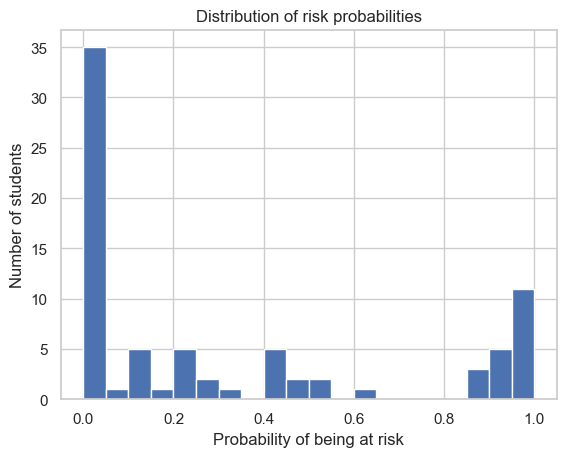

In [101]:
# (optional) 
plt.hist(y_prob, bins=20)
plt.title("Distribution of risk probabilities")
plt.xlabel("Probability of being at risk")
plt.ylabel("Number of students")

plt.savefig("../src/distribution_risk_proba.png")
plt.show()

In [48]:
# Display students at risk
indices = np.argsort(y_prob)[-10:]  # 10 highest probabilities

for i in indices:
    print(f"Student {i} → probability risk: {y_prob[i]:.2f}")

Student 34 → probability risk: 0.98
Student 72 → probability risk: 0.98
Student 4 → probability risk: 0.99
Student 59 → probability risk: 0.99
Student 54 → probability risk: 0.99
Student 33 → probability risk: 1.00
Student 0 → probability risk: 1.00
Student 67 → probability risk: 1.00
Student 13 → probability risk: 1.00
Student 20 → probability risk: 1.00


In [49]:
# Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
# 89-90% of students are correctly classified
# but accuracy alone mat hide problems in imbalanced datasets => use other metrics

Accuracy: 0.8987341772151899


In [50]:
# Confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)
# 51 safe students correctly predicted
# 20 risk students correctly detected

# 2 safe students wrongly flagged as risk
# 6 risk students who failed but were predicted safe

[[51  2]
 [ 6 20]]


In [51]:
# Classification report : computes Precision, Recall, F1-score, support
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.96      0.93        53
           1       0.91      0.77      0.83        26

    accuracy                           0.90        79
   macro avg       0.90      0.87      0.88        79
weighted avg       0.90      0.90      0.90        79



In [52]:
"""
Class 0 (safe) :
- precision : 0.89 => of all students predicted 'safe', 89% truly safe (correct 89% of the time)
- recall : 0.96 => 96% of safe students were correctly identified

Class 1 (risk) :
- precision : 0.91 => of all students predicted 'risk', 91% truly at risk
- recall : 0.77 => of all students actually at risk, model detects 77% of them (77% students at risk are well predicted)
=> problem: missing 23% of at risk students !!
"""

"\nClass 0 (safe) :\n- precision : 0.89 => of all students predicted 'safe', 89% truly safe (correct 89% of the time)\n- recall : 0.96 => 96% of safe students were correctly identified\n\nClass 1 (risk) :\n- precision : 0.91 => of all students predicted 'risk', 91% truly at risk\n- recall : 0.77 => of all students actually at risk, model detects 77% of them (77% students at risk are well predicted)\n=> problem: missing 23% of at risk students !!\n"

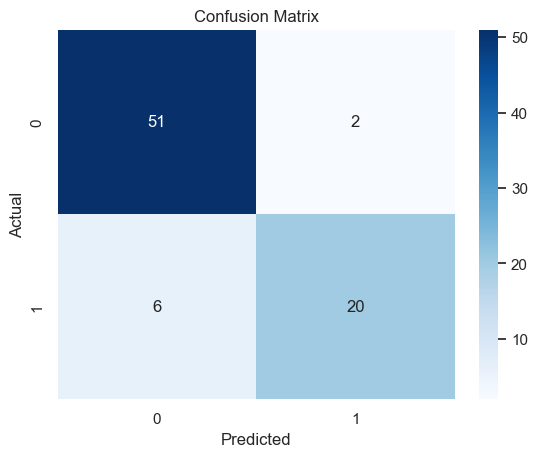

In [102]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("../src/confusion_matrix.png")
plt.show()

In [54]:
### Train several different Machine Learning models: Decision Tree, Random Forest, k-NN ###
### Analyse which one works best !! ##

In [55]:
# K-Nearest Neighbors (k-NN) model
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

# training 
knn.fit(X_train_scaled, y_train) 

# prediction
y_pred_knn = knn.predict(X_test_scaled) 
y_prob_knn = knn.predict_proba(X_test_scaled)[:, 1]

In [56]:
#y_pred_knn

In [57]:
y_prob_knn

array([0.2, 0. , 0.4, 0.2, 0.6, 0.4, 0.4, 0. , 0.8, 0.4, 0.2, 0.2, 0.2,
       0.6, 0. , 0.4, 0.4, 0.2, 0. , 0. , 0.6, 0.2, 0.4, 0.6, 0.4, 0.2,
       0.6, 0.2, 0.6, 0.2, 0. , 0. , 0. , 0. , 0.4, 0. , 0.4, 0.2, 0.2,
       0. , 0.4, 0.2, 0.6, 0.4, 0.8, 0.4, 0.4, 0. , 0. , 0.2, 0.2, 0.6,
       0.2, 0.2, 1. , 0.8, 0.4, 0.2, 0. , 0.2, 0.2, 0. , 0. , 0.6, 0. ,
       0. , 0.2, 0.8, 0.4, 0.6, 0.2, 0.4, 0.6, 0.2, 0.2, 0.6, 0.4, 0.4,
       0.6])

In [58]:
# Accuracy
from sklearn.metrics import accuracy_score

accuracy_knn = accuracy_score(y_test, y_pred_knn)
print("Accuracy:", accuracy_knn)

Accuracy: 0.7974683544303798


In [59]:
# Confusion matrix
from sklearn.metrics import confusion_matrix

cm_knn = confusion_matrix(y_test, y_pred_knn)
print(cm_knn)

[[49  4]
 [12 14]]


In [60]:
# Classification report : computes Precision, Recall, F1-score, support
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.80      0.92      0.86        53
           1       0.78      0.54      0.64        26

    accuracy                           0.80        79
   macro avg       0.79      0.73      0.75        79
weighted avg       0.79      0.80      0.79        79



In [61]:
# Decision Tree model 
from sklearn.tree import DecisionTreeClassifier

dec_tree = DecisionTreeClassifier(random_state=42)

# training
dec_tree.fit(X_train_scaled, y_train)

# prediction 
y_pred_dt = dec_tree.predict(X_test_scaled) 
y_prob_dt = dec_tree.predict_proba(X_test_scaled)[:,1]

In [62]:
#y_pred_dt

In [63]:
y_prob_dt 

array([1., 0., 1., 1., 1., 0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0.,
       1., 0., 0., 1., 0., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 1.,
       1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 0., 0., 0., 1.,
       1., 0., 0., 1., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 1.,
       1., 0., 0., 0., 1., 0., 0., 0., 0., 0., 1.])

In [64]:
# Accuracy
from sklearn.metrics import accuracy_score

accuracy_dt = accuracy_score(y_test, y_pred_dt)
print("Accuracy:", accuracy_dt)

Accuracy: 0.8607594936708861


In [65]:
# Confusion matrix
from sklearn.metrics import confusion_matrix

cm_dt = confusion_matrix(y_test, y_pred_dt)
print(cm_dt)

[[47  6]
 [ 5 21]]


In [66]:
# Classification report : computes Precision, Recall, F1-score, support
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.90      0.89      0.90        53
           1       0.78      0.81      0.79        26

    accuracy                           0.86        79
   macro avg       0.84      0.85      0.84        79
weighted avg       0.86      0.86      0.86        79



In [67]:
# Random Forest model
from sklearn.ensemble import RandomForestClassifier

ran_for = RandomForestClassifier(n_estimators=100, random_state=42)

# training 
ran_for.fit(X_train_scaled, y_train)

# prediction
y_pred_rf = ran_for.predict(X_test_scaled) 
y_prob_rf = ran_for.predict_proba(X_test_scaled)[:,1]

In [68]:
#y_pred_rf

In [69]:
y_prob_rf

array([0.75, 0.26, 0.6 , 0.71, 0.67, 0.1 , 0.26, 0.08, 0.64, 0.15, 0.07,
       0.13, 0.07, 0.63, 0.13, 0.09, 0.07, 0.64, 0.07, 0.02, 0.73, 0.06,
       0.59, 0.67, 0.27, 0.02, 0.73, 0.76, 0.35, 0.02, 0.12, 0.22, 0.04,
       0.67, 0.8 , 0.04, 0.03, 0.08, 0.12, 0.04, 0.29, 0.25, 0.07, 0.26,
       0.88, 0.77, 0.63, 0.05, 0.38, 0.57, 0.56, 0.7 , 0.07, 0.26, 0.84,
       0.25, 0.04, 0.09, 0.04, 0.7 , 0.05, 0.07, 0.02, 0.67, 0.03, 0.31,
       0.54, 0.9 , 0.38, 0.28, 0.11, 0.21, 0.89, 0.12, 0.06, 0.13, 0.09,
       0.07, 0.79])

In [70]:
# Accuracy
from sklearn.metrics import accuracy_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)
print("Accuracy:", accuracy_rf)

Accuracy: 0.9113924050632911


In [71]:
# Confusion matrix
from sklearn.metrics import confusion_matrix

cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

[[49  4]
 [ 3 23]]


In [72]:
# Classification report : computes Precision, Recall, F1-score, support
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.94      0.92      0.93        53
           1       0.85      0.88      0.87        26

    accuracy                           0.91        79
   macro avg       0.90      0.90      0.90        79
weighted avg       0.91      0.91      0.91        79



In [73]:
print("Model comparison :")
results = {
    "Logistic Regression": accuracy,
    "Decision Tree": accuracy_dt,
    "Random Forest": accuracy_rf,
    "KNN": accuracy_knn
}

print(results)

Model comparison :
{'Logistic Regression': 0.8987341772151899, 'Decision Tree': 0.8607594936708861, 'Random Forest': 0.9113924050632911, 'KNN': 0.7974683544303798}


In [74]:
### Part 6: Interpretation & Feature Importance ###

In [78]:
### 6.1 Feature importance with Random Forest ###
# Extract feature importances # 
feature_importance_rf = pd.Series(ran_for.feature_importances_, index=X_train.columns).sort_values(ascending=False)
feature_importance_rf.head(10) # 10 most important features

G2          0.307881
G1          0.209980
absences    0.035624
failures    0.029135
goout       0.023811
Fedu        0.022199
age         0.020906
famrel      0.017700
health      0.016931
Walc        0.014927
dtype: float64

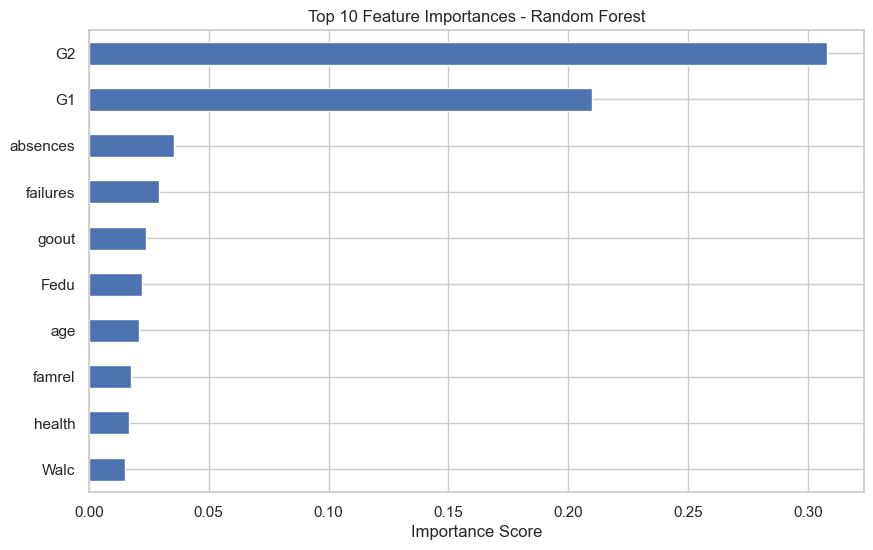

In [103]:
# Visualisation
top10_rf = feature_importance_rf.head(10)
plt.figure(figsize=(10,6))
top10_rf.sort_values().plot(kind="barh") # horizontal bar 
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance Score")

plt.savefig("../src/importance_score.png")
plt.show()

In [ ]:
"""
Observation: 
G2          0.30
G1          0.21
Others:     0.02 - 0.03 

=> Conclusion: The model relies heavily on academic features, and much less on all other. 
- Student's academic trajectory (1st & 2nd period grades and past failures) is the strongest indicator of final performance. 
- Student's habit and engagement (attendance - 'absences', social activity - 'goout', 'Walc', 'heath' do influence performance,
but much more weaker than academic histoty. 
- Family background, social factors: 'Fedu', 'famrel' influence moderately to student's performance, 
suggesting a supportive environment may help but it's not the main factor. 
"""

In [81]:
### 6.2 — Logistic Regression Coefficients ###
coef_lr = pd.Series(log_reg.coef_[0], index=X_train.columns).sort_values()  
coef_lr

G2                  -4.214133
G1                  -1.907213
famrel              -0.775536
Walc                -0.523586
Fjob_other          -0.444825
traveltime          -0.282417
sex_F               -0.188339
activities_no       -0.185088
freetime            -0.173221
guardian_father     -0.168368
reason_home         -0.161090
nursery_no          -0.158721
Mjob_at_home        -0.157308
famsup_no           -0.155192
Pstatus_A           -0.148128
school_MS           -0.143352
Fjob_at_home        -0.139313
Mjob_services       -0.138927
reason_other        -0.137379
famsize_GT3         -0.133317
failures            -0.129366
romantic_no         -0.119827
Mjob_teacher        -0.078573
address_U           -0.062861
internet_yes        -0.060547
higher_no           -0.032588
guardian_mother     -0.024004
paid_yes            -0.017424
Fjob_teacher        -0.014130
schoolsup_yes       -0.012435
schoolsup_no         0.012435
Fedu                 0.015566
paid_no              0.017424
higher_yes

In [86]:
print("Most negative coefficients (protective factors) : ")
print(coef_lr.head(10))
# higher, much safer (reduce risk)

Most negative coefficients (protective factors) : 
G2                -4.214133
G1                -1.907213
famrel            -0.775536
Walc              -0.523586
Fjob_other        -0.444825
traveltime        -0.282417
sex_F             -0.188339
activities_no     -0.185088
freetime          -0.173221
guardian_father   -0.168368
dtype: float64


In [87]:
print("Most positive coefficients (risk factors) : ")
print(coef_lr.tail(10))
# higher, more risk (increase risk) 

Most positive coefficients (risk factors) : 
reason_course     0.193099
studytime         0.199800
Mjob_other        0.261181
absences          0.296229
guardian_other    0.299814
Dalc              0.302601
goout             0.321095
Fjob_health       0.343996
Fjob_services     0.384184
age               0.678533
dtype: float64


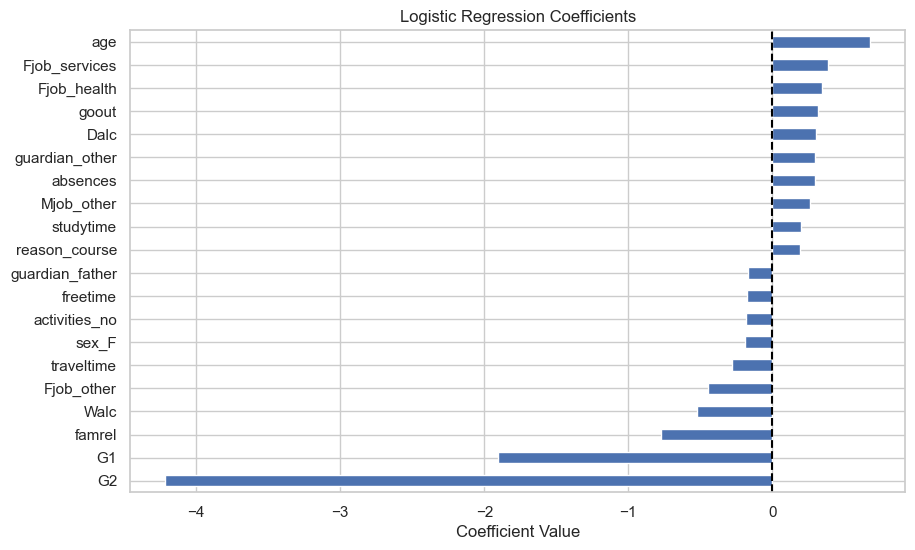

In [104]:
top_positive = coef_lr.tail(10)
top_negative = coef_lr.head(10)

important_lr = pd.concat([top_negative, top_positive])

plt.figure(figsize=(10,6))
important_lr.sort_values().plot(kind="barh")
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.axvline(0, color="black", linestyle="--")

plt.savefig("../src/Logistic_regression_coefs.png")
plt.show()